# 04 - Uncertainty Modelling

In this notebook I define how uncertainty will be applied to the nominal cooling-load values before the Monte Carlo simulation is built.

Notebook 03 showed that the deterministic assessment passes in both Scenario Alpha and Scenario Bravo, but several subsystems are close enough to capacity that uncertainty could still be important. This notebook therefore prepares the uncertainty assumptions that will be used in Notebook 05.

## Purpose of this notebook

The aim of this stage is not to run the full Monte Carlo simulation yet. Instead, I define and check the load sampling assumptions.

The notebook:

* recreates the local modelling dataset from the updated workbook;
* excludes embedded propagation rows from downstream local sampling;
* creates margin cases A, B and C;
* defines triangular and truncated normal distribution parameters;
* uses a 95% interval assumption for the truncated normal standard deviation;
* checks that sampled values are non-negative and remain inside the defined uncertainty bounds.

## Import libraries and set file paths

I keep the code inside this notebook so that the modelling assumptions are visible and reproducible.

In [1]:
# Importing the required libraries
from pathlib import Path
import pandas as pd
import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False
    print("matplotlib and seaborn are not installed yet, so plots will be skipped.")

try:
    from scipy.stats import truncnorm
    scipy_available = True
except ModuleNotFoundError:
    scipy_available = False
    print("scipy is not installed yet, so truncated normal sampling checks will be skipped.")

# Find the project root. This works if the notebook is run from the repo root or from the notebooks folder.
current_path = Path.cwd().resolve()
if (current_path / "data" / "raw" / "data.xlsx").exists():
    project_root = current_path
elif (current_path.parent / "data" / "raw" / "data.xlsx").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Could not find data/raw/data.xlsx. Please open VS Code at the repository folder.")

raw_data_path = project_root / "data" / "raw" / "data.xlsx"
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"

tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

random_seed = 19046600
rng = np.random.default_rng(random_seed)

print(f"Project root: {project_root}")
print(f"Raw data path: {raw_data_path}")
# Consistent project colours used in all notebook figures
SYSTEM_ORDER = ["HVAC", "CW", "FW"]
SYSTEM_PALETTE = {
    "HVAC": "#7b5aa6",
    "CW": "#3f83a3",
    "FW": "#5f9f77",
    "Ultimate Heat Sink": "#d78b4b",
}
SYSTEM_COLOUR_LIST = [SYSTEM_PALETTE[system] for system in SYSTEM_ORDER]
SCENARIO_PALETTE = {
    "Scenario Alpha": SYSTEM_PALETTE["HVAC"],
    "Scenario Bravo": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DISTRIBUTION_PALETTE = {
    "Triangular": SYSTEM_PALETTE["CW"],
    "Truncated normal": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DEPENDENCY_PALETTE = {
    "Independent": "#6f7b82",
    "Global Gaussian copula": SYSTEM_PALETTE["HVAC"],
    "Subsystem-block Gaussian copula": SYSTEM_PALETTE["CW"],
}

print(f"Random seed: {random_seed}")

Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Raw data path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\data\raw\data.xlsx
Random seed: 19046600


## Load the workbook

I load the updated workbook directly. This keeps the uncertainty modelling aligned with the EDA and deterministic baseline notebooks.

In [2]:
# Load the workbook
excel_file = pd.ExcelFile(raw_data_path)
sheet_names = excel_file.sheet_names
raw_data = pd.read_excel(raw_data_path, sheet_name=sheet_names[0])

print("Sheet names in workbook:")
print(sheet_names)
print(f"Raw dataset shape: {raw_data.shape[0]} rows and {raw_data.shape[1]} columns")
display(raw_data.head())

Sheet names in workbook:
['data']
Raw dataset shape: 2457 rows and 37 columns


,PBS Code,Teamcenter ID,BOM ID,Item Description,HVAC Load,HVAC Scenario Alpha Lf,HVAC Scenario Alpha Uf,HVAC Scenario Alpha Load,HVAC Scenario Bravo Lf,HVAC Scenario Bravo Uf,...,FW Scenario Alpha Lf,FW Scenario Alpha Uf,FW Scenario Alpha Load,FW Scenario Bravo Lf,FW Scenario Bravo Uf,FW Scenario Bravo Load,FW CMM,FW CUM,FW DBM,FW IGM
0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PBS_GROUP_0001,NaN,BOM_000002,ITEM_000002,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PBS_GROUP_0001,NaN,BOM_000003,ITEM_000003,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PBS_GROUP_0001,NaN,BOM_000004,ITEM_000004,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PBS_GROUP_0001,NaN,BOM_000005,ITEM_000005,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Recreate the local modelling dataset

I reshape the workbook into one row per source row and subsystem. This is similar to Notebook 02, but here I keep only the fields needed for uncertainty modelling.

The embedded propagation rows are flagged so they can be excluded from local downstream sampling:

* `ITEM_000955` is excluded from local CW sampling;
* `ITEM_001103` is excluded from local FW sampling.

These upstream loads will be replaced later by sampled upstream totals in the Monte Carlo cascade.

In [3]:
systems = ["HVAC", "CW", "FW"]
records = []

for row_number, row in raw_data.iterrows():
    for system in systems:
        system_columns = {
            "alpha_load_kw": f"{system} Scenario Alpha Load",
            "bravo_load_kw": f"{system} Scenario Bravo Load",
            "cmm": f"{system} CMM",
            "cum": f"{system} CUM",
            "dbm": f"{system} DBM",
            "igm": f"{system} IGM"
        }

        if all(pd.isna(row[column]) for column in system_columns.values()):
            continue

        record = {
            "source_row": row_number,
            "record_id": row_number + 1,
            "pbs_code": row["PBS Code"],
            "teamcenter_id": row["Teamcenter ID"],
            "bom_id": row["BOM ID"],
            "item_description": row["Item Description"],
            "system": system
        }

        for new_column, original_column in system_columns.items():
            record[new_column] = pd.to_numeric(row[original_column], errors="coerce")

        for scenario in ["alpha", "bravo"]:
            load_column = f"{scenario}_load_kw"
            record[f"{scenario}_load_was_blank"] = pd.isna(record[load_column])
            record[f"{scenario}_load_model_kw"] = 0 if pd.isna(record[load_column]) else record[load_column]

        for margin_column in ["cmm", "cum", "dbm", "igm"]:
            record[f"{margin_column}_was_blank"] = pd.isna(record[margin_column])
            record[f"{margin_column}_model"] = 0 if pd.isna(record[margin_column]) else record[margin_column]

        record["is_propagation_row"] = (
            (system == "CW" and row["Item Description"] == "ITEM_000955") or
            (system == "FW" and row["Item Description"] == "ITEM_001103")
        )

        if system == "CW" and row["Item Description"] == "ITEM_000955":
            record["propagation_type"] = "hvac_to_cw"
        elif system == "FW" and row["Item Description"] == "ITEM_001103":
            record["propagation_type"] = "cw_to_fw"
        else:
            record["propagation_type"] = "local"

        record["margin_case_a"] = record["cum_model"]
        record["margin_case_b"] = record["cmm_model"] + record["cum_model"]
        record["margin_case_c"] = (
            record["cmm_model"] + record["cum_model"] + record["dbm_model"] + record["igm_model"]
        )

        records.append(record)

modelling_records = pd.DataFrame(records)
local_records = modelling_records[~modelling_records["is_propagation_row"]].copy()

print(f"All subsystem records: {len(modelling_records)}")
print(f"Local records used for uncertainty modelling: {len(local_records)}")
display(local_records.head())

All subsystem records: 2591
Local records used for uncertainty modelling: 2589


,source_row,record_id,pbs_code,teamcenter_id,bom_id,item_description,system,alpha_load_kw,bravo_load_kw,cmm,...,cum_model,dbm_was_blank,dbm_model,igm_was_blank,igm_model,is_propagation_row,propagation_type,margin_case_a,margin_case_b,margin_case_c
0,0,1,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,14.872000,0.000000,0.1,...,0.15,False,0.1,False,0.0,False,local,0.15,0.25,0.35
1,1,2,PBS_GROUP_0001,NaN,BOM_000002,ITEM_000002,CW,9.668000,9.668000,0.1,...,0.15,False,0.1,False,0.0,False,local,0.15,0.25,0.35
2,2,3,PBS_GROUP_0001,NaN,BOM_000003,ITEM_000003,CW,9.368000,9.368000,0.1,...,0.15,False,0.1,False,0.0,False,local,0.15,0.25,0.35
3,3,4,PBS_GROUP_0001,NaN,BOM_000004,ITEM_000004,CW,3.119780,1.500141,0.1,...,0.15,False,0.1,False,0.0,False,local,0.15,0.25,0.35
4,4,5,PBS_GROUP_0001,NaN,BOM_000005,ITEM_000005,CW,3.485204,3.638000,0.1,...,0.15,False,0.1,False,0.0,False,local,0.15,0.25,0.35


## Check excluded propagation rows

I check the excluded rows explicitly because this is the main step that prevents the Monte Carlo model from double-counting cascaded loads.

In [4]:
excluded_propagation_rows = modelling_records[modelling_records["is_propagation_row"]].copy()

excluded_columns = [
    "source_row", "record_id", "item_description", "system", "propagation_type",
    "alpha_load_model_kw", "bravo_load_model_kw"
]

excluded_propagation_rows = excluded_propagation_rows[excluded_columns]
excluded_propagation_rows.to_csv(tables_output_path / "uncertainty_excluded_propagation_rows.csv", index=False)
display(excluded_propagation_rows)

,source_row,record_id,item_description,system,propagation_type,alpha_load_model_kw,bravo_load_model_kw
1080,995,996,ITEM_000955,CW,hvac_to_cw,1026.76,307.29
1284,1194,1195,ITEM_001103,FW,cw_to_fw,3814.64,1256.64


## Why these uncertainty distributions are used

There is no measured operating data available for this project. Because of this, I cannot fit a probability distribution from historical plant data. The uncertainty model is therefore based on engineering judgement around the nominal load values in the workbook.

I use two bounded distributions:

* **Triangular distribution**: this is useful when the lower value, most likely value and upper value can be estimated, but there is not enough evidence to justify a more detailed distribution. In this project the nominal load is treated as the most likely value.
* **Truncated normal distribution**: this is used as a comparison case. It puts more probability close to the nominal load, but it is cut off at the same lower and upper engineering bounds so that unrealistic loads are not sampled.

Using both distributions helps check whether the Monte Carlo result depends strongly on the assumed shape of the uncertainty distribution. If the result only appeared under one distribution, I would need to treat it more cautiously.

## Margin cases

I use the three margin cases agreed for the project:

* Case A = `CUM`
* Case B = `CMM + CUM`
* Case C = `CMM + CUM + DBM + IGM`

These are treated as uncertainty assumptions rather than as a single correct interpretation of the engineering margins.

In [5]:
margin_case_summary = (
    local_records
    .groupby("system")
    .agg(
        records=("record_id", "count"),
        case_a_mean=("margin_case_a", "mean"),
        case_a_max=("margin_case_a", "max"),
        case_b_mean=("margin_case_b", "mean"),
        case_b_max=("margin_case_b", "max"),
        case_c_mean=("margin_case_c", "mean"),
        case_c_max=("margin_case_c", "max")
    )
    .reset_index()
)

margin_case_summary.to_csv(tables_output_path / "uncertainty_margin_case_summary.csv", index=False)
display(margin_case_summary)

,system,records,case_a_mean,case_a_max,case_b_mean,case_b_max,case_c_mean,case_c_max
0,CW,198,0.059848,0.15,0.146717,0.25,0.207222,0.35
1,FW,65,0.000000,0.00,0.000000,0.00,0.106923,0.13
2,HVAC,2326,0.017992,0.15,0.090993,0.25,0.127511,0.35


## How the distribution parameters are calculated

For each local load row, I start with the nominal scenario load from the workbook. I then apply the selected uncertainty margin, written here as `u`. The lower and upper engineering bounds are calculated as:

```text
lower = max(0, nominal load x (1 - u))
upper = nominal load x (1 + u)
```

The `max(0, ...)` part is included because a cooling load cannot be negative.

For the triangular distribution, the parameters are:

```text
minimum = lower
mode    = nominal load
maximum = upper
```

For the truncated normal distribution, the nominal load is treated as the mean. The lower and upper bounds are treated as an approximate 95% interval around the nominal value. This gives:

```text
mean  = nominal load
sigma = (u x nominal load) / 1.96
lower truncation point = lower
upper truncation point = upper
```

This means the normal distribution is centred on the engineering estimate, but the samples are still forced to remain inside the same physical bounds used by the triangular distribution. If a row has zero nominal load or zero uncertainty, it is treated as fixed rather than randomly sampled.

## Define distribution parameter tables

For each local load record, scenario and margin case, I define parameters for two distributions.

**Triangular distribution**

```text
lower = max(0, nominal * (1 - uncertainty_pct))
mode  = nominal
upper = nominal * (1 + uncertainty_pct)
```

**Truncated normal distribution**

```text
mean  = nominal
lower = max(0, nominal * (1 - uncertainty_pct))
upper = nominal * (1 + uncertainty_pct)
sigma = (uncertainty_pct * nominal) / 1.96
```

The `1.96` value means I am treating the uncertainty band as an approximate 95% interval around the nominal load before truncation. If the nominal load or uncertainty percentage is zero, the sampled value should remain equal to the nominal load.

In [6]:
parameter_rows = []

margin_cases = {
    "Case A - CUM": "margin_case_a",
    "Case B - CMM + CUM": "margin_case_b",
    "Case C - CMM + CUM + DBM + IGM": "margin_case_c"
}

scenarios = {
    "Scenario Alpha": "alpha_load_model_kw",
    "Scenario Bravo": "bravo_load_model_kw"
}

for _, row in local_records.iterrows():
    for scenario_name, load_column in scenarios.items():
        nominal_load = float(row[load_column])

        for margin_case_name, margin_column in margin_cases.items():
            uncertainty_pct = float(row[margin_column])
            lower = max(0, nominal_load * (1 - uncertainty_pct))
            upper = nominal_load * (1 + uncertainty_pct)

            if nominal_load == 0 or uncertainty_pct == 0:
                sigma = 0
            else:
                sigma = (uncertainty_pct * nominal_load) / 1.96

            parameter_rows.append({
                "record_id": row["record_id"],
                "source_row": row["source_row"],
                "pbs_code": row["pbs_code"],
                "teamcenter_id": row["teamcenter_id"],
                "bom_id": row["bom_id"],
                "item_description": row["item_description"],
                "system": row["system"],
                "scenario": scenario_name,
                "margin_case": margin_case_name,
                "nominal_load_kw": nominal_load,
                "uncertainty_pct": uncertainty_pct,
                "triangular_lower_kw": lower,
                "triangular_mode_kw": nominal_load,
                "triangular_upper_kw": upper,
                "truncnorm_lower_kw": lower,
                "truncnorm_mean_kw": nominal_load,
                "truncnorm_upper_kw": upper,
                "truncnorm_sigma_kw": sigma,
                "is_degenerate": nominal_load == 0 or uncertainty_pct == 0
            })

distribution_parameters = pd.DataFrame(parameter_rows)
distribution_parameters.to_csv(tables_output_path / "uncertainty_distribution_parameters.csv", index=False)

print(f"Distribution parameter rows: {len(distribution_parameters)}")
display(distribution_parameters.head())

Distribution parameter rows: 15534


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,scenario,margin_case,nominal_load_kw,uncertainty_pct,triangular_lower_kw,triangular_mode_kw,triangular_upper_kw,truncnorm_lower_kw,truncnorm_mean_kw,truncnorm_upper_kw,truncnorm_sigma_kw,is_degenerate
0,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case A - CUM,14.872,0.15,12.6412,14.872,17.1028,12.6412,14.872,17.1028,1.138163,False
1,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case B - CMM + CUM,14.872,0.25,11.1540,14.872,18.5900,11.1540,14.872,18.5900,1.896939,False
2,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,14.872,0.35,9.6668,14.872,20.0772,9.6668,14.872,20.0772,2.655714,False
3,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Bravo,Case A - CUM,0.000,0.15,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.000000,True
4,1,0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,Scenario Bravo,Case B - CMM + CUM,0.000,0.25,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.000000,True


## Parameter summary

I summarise the parameter table to check that the uncertainty cases behave as expected. Case C should generally create the widest uncertainty bands.

In [7]:
parameter_summary = (
    distribution_parameters
    .groupby(["system", "scenario", "margin_case"])
    .agg(
        records=("record_id", "count"),
        positive_nominal_records=("nominal_load_kw", lambda x: (x > 0).sum()),
        mean_nominal_load_kw=("nominal_load_kw", "mean"),
        max_nominal_load_kw=("nominal_load_kw", "max"),
        mean_uncertainty_pct=("uncertainty_pct", "mean"),
        max_uncertainty_pct=("uncertainty_pct", "max"),
        mean_sigma_kw=("truncnorm_sigma_kw", "mean"),
        max_upper_kw=("triangular_upper_kw", "max")
    )
    .reset_index()
)

parameter_summary.to_csv(tables_output_path / "uncertainty_parameter_summary.csv", index=False)
display(parameter_summary)

,system,scenario,margin_case,records,positive_nominal_records,mean_nominal_load_kw,max_nominal_load_kw,mean_uncertainty_pct,max_uncertainty_pct,mean_sigma_kw,max_upper_kw
0,CW,Scenario Alpha,Case A - CUM,198,181,14.080192,314.683,0.059848,0.15,0.145215,314.68300
1,CW,Scenario Alpha,Case B - CMM + CUM,198,181,14.080192,314.683,0.146717,0.25,0.441248,314.68300
2,CW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,198,181,14.080192,314.683,0.207222,0.35,0.653025,314.68300
3,CW,Scenario Bravo,Case A - CUM,198,101,4.794678,83.136,0.059848,0.15,0.081204,83.13600
4,CW,Scenario Bravo,Case B - CMM + CUM,198,101,4.794678,83.136,0.146717,0.25,0.242075,91.44960
5,CW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,198,101,4.794678,83.136,0.207222,0.35,0.349014,94.77504
6,FW,Scenario Alpha,Case A - CUM,65,56,113.196217,2349.966,0.000000,0.00,0.000000,2349.96600
7,FW,Scenario Alpha,Case B - CMM + CUM,65,56,113.196217,2349.966,0.000000,0.00,0.000000,2349.96600
8,FW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,65,56,113.196217,2349.966,0.106923,0.13,4.413396,2584.96260
9,FW,Scenario Bravo,Case A - CUM,65,39,51.995057,886.459,0.000000,0.00,0.000000,886.45900


## Sampling functions for validation

I define simple sampling functions so that I can validate the assumptions before running the full Monte Carlo simulation in Notebook 05.

In [8]:
def sample_triangular(row, sample_size, rng):
    nominal = row["nominal_load_kw"]
    lower = row["triangular_lower_kw"]
    upper = row["triangular_upper_kw"]

    if row["is_degenerate"]:
        return np.full(sample_size, nominal)

    return rng.triangular(lower, nominal, upper, sample_size)


def sample_truncated_normal(row, sample_size, rng):
    nominal = row["nominal_load_kw"]
    lower = row["truncnorm_lower_kw"]
    upper = row["truncnorm_upper_kw"]
    sigma = row["truncnorm_sigma_kw"]

    if row["is_degenerate"]:
        return np.full(sample_size, nominal)

    if not scipy_available:
        raise ModuleNotFoundError("scipy is required for truncated normal sampling.")

    a = (lower - nominal) / sigma
    b = (upper - nominal) / sigma
    return truncnorm.rvs(a, b, loc=nominal, scale=sigma, size=sample_size, random_state=rng)

## Validate example sampling

I select one positive-load record for each system and scenario. I use the largest non-zero uncertain load within each group, so this remains a simple validation check rather than the final Monte Carlo simulation.


In [9]:
positive_parameters = distribution_parameters[
    (distribution_parameters["nominal_load_kw"] > 0) &
    (distribution_parameters["uncertainty_pct"] > 0)
].copy()

system_order = ["HVAC", "CW", "FW"]
scenario_order = ["Scenario Alpha", "Scenario Bravo"]

example_parameters = (
    positive_parameters
    .sort_values("nominal_load_kw", ascending=False)
    .groupby(["system", "scenario"])
    .head(1)
    .assign(
        system=lambda frame: pd.Categorical(frame["system"], categories=system_order, ordered=True),
        scenario=lambda frame: pd.Categorical(frame["scenario"], categories=scenario_order, ordered=True)
    )
    .sort_values(["scenario", "system"])
    .reset_index(drop=True)
)

example_parameters.to_csv(tables_output_path / "uncertainty_example_parameter_rows.csv", index=False)
display(example_parameters)


,record_id,source_row,pbs_code,teamcenter_id,bom_id,item_description,system,scenario,margin_case,nominal_load_kw,uncertainty_pct,triangular_lower_kw,triangular_mode_kw,triangular_upper_kw,truncnorm_lower_kw,truncnorm_mean_kw,truncnorm_upper_kw,truncnorm_sigma_kw,is_degenerate
0,2454,2453,PBS_GROUP_SMALL,TC_001877,BOM_000061,ITEM_001725,HVAC,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,80.907000,0.14,69.58002,80.907000,92.233980,69.58002,80.907000,92.233980,5.779071,False
1,821,820,PBS_GROUP_SMALL,TC_000754,BOM_000801,ITEM_000789,CW,Scenario Alpha,Case B - CMM + CUM,159.396066,0.10,143.45646,159.396066,175.335673,143.45646,159.396066,175.335673,8.132452,False
2,92,91,PBS_GROUP_SMALL,TC_000025,BOM_000074,ITEM_000091,FW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,2349.966000,0.10,2114.96940,2349.966000,2584.962600,2114.96940,2349.966000,2584.962600,119.896224,False
3,153,152,PBS_GROUP_SMALL,TC_000086,BOM_000134,ITEM_000132,HVAC,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,48.583000,0.14,41.78138,48.583000,55.384620,41.78138,48.583000,55.384620,3.470214,False
4,1190,1189,PBS_GROUP_0034,TC_001123,BOM_001169,ITEM_001098,CW,Scenario Bravo,Case B - CMM + CUM,83.136000,0.10,74.82240,83.136000,91.449600,74.82240,83.136000,91.449600,4.241633,False
5,76,75,PBS_GROUP_0006,TC_000009,BOM_000058,ITEM_000076,FW,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,886.459000,0.13,771.21933,886.459000,1001.698670,771.21933,886.459000,1001.698670,58.795750,False


In [10]:
validation_rows = []
sample_size = 5000

for _, row in example_parameters.iterrows():
    triangular_samples = sample_triangular(row, sample_size, rng)

    validation_rows.append({
        "distribution": "Triangular",
        "system": row["system"],
        "scenario": row["scenario"],
        "margin_case": row["margin_case"],
        "record_id": row["record_id"],
        "nominal_load_kw": row["nominal_load_kw"],
        "lower_kw": row["triangular_lower_kw"],
        "upper_kw": row["triangular_upper_kw"],
        "sample_mean_kw": triangular_samples.mean(),
        "sample_min_kw": triangular_samples.min(),
        "sample_max_kw": triangular_samples.max(),
        "non_negative_check": bool((triangular_samples >= 0).all()),
        "within_bounds_check": bool(
            (triangular_samples >= row["triangular_lower_kw"]).all() and
            (triangular_samples <= row["triangular_upper_kw"]).all()
        )
    })

    if scipy_available:
        truncnorm_samples = sample_truncated_normal(row, sample_size, rng)

        validation_rows.append({
            "distribution": "Truncated normal",
            "system": row["system"],
            "scenario": row["scenario"],
            "margin_case": row["margin_case"],
            "record_id": row["record_id"],
            "nominal_load_kw": row["nominal_load_kw"],
            "lower_kw": row["truncnorm_lower_kw"],
            "upper_kw": row["truncnorm_upper_kw"],
            "sample_mean_kw": truncnorm_samples.mean(),
            "sample_min_kw": truncnorm_samples.min(),
            "sample_max_kw": truncnorm_samples.max(),
            "non_negative_check": bool((truncnorm_samples >= 0).all()),
            "within_bounds_check": bool(
                (truncnorm_samples >= row["truncnorm_lower_kw"]).all() and
                (truncnorm_samples <= row["truncnorm_upper_kw"]).all()
            )
        })

sampling_validation = pd.DataFrame(validation_rows)
sampling_validation.to_csv(tables_output_path / "uncertainty_sampling_validation.csv", index=False)
display(sampling_validation)

,distribution,system,scenario,margin_case,record_id,nominal_load_kw,lower_kw,upper_kw,sample_mean_kw,sample_min_kw,sample_max_kw,non_negative_check,within_bounds_check
0,Triangular,HVAC,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,2454,80.907000,69.58002,92.233980,80.912287,69.597465,92.125526,True,True
1,Truncated normal,HVAC,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,2454,80.907000,69.58002,92.233980,81.079485,69.642283,92.229533,True,True
2,Triangular,CW,Scenario Alpha,Case B - CMM + CUM,821,159.396066,143.45646,175.335673,159.539404,143.671739,174.920411,True,True
3,Truncated normal,CW,Scenario Alpha,Case B - CMM + CUM,821,159.396066,143.45646,175.335673,159.474329,143.456612,175.267216,True,True
4,Triangular,FW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,92,2349.966000,2114.96940,2584.962600,2349.988945,2118.752042,2582.872500,True,True
5,Truncated normal,FW,Scenario Alpha,Case C - CMM + CUM + DBM + IGM,92,2349.966000,2114.96940,2584.962600,2349.004878,2115.062497,2584.863102,True,True
6,Triangular,HVAC,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,153,48.583000,41.78138,55.384620,48.606207,42.028115,55.231940,True,True
7,Truncated normal,HVAC,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,153,48.583000,41.78138,55.384620,48.592846,41.809748,55.380053,True,True
8,Triangular,CW,Scenario Bravo,Case B - CMM + CUM,1190,83.136000,74.82240,91.449600,83.134578,74.940089,91.139708,True,True
9,Truncated normal,CW,Scenario Bravo,Case B - CMM + CUM,1190,83.136000,74.82240,91.449600,83.192993,74.833185,91.418286,True,True


## Zero-load and zero-uncertainty checks

Records with zero nominal load or zero uncertainty should not vary when sampled. This is important because blank scenario fields were converted to zero for modelling.

In [11]:
degenerate_parameters = distribution_parameters[distribution_parameters["is_degenerate"]].copy()

degenerate_check_rows = []
for _, row in degenerate_parameters.head(20).iterrows():
    triangular_samples = sample_triangular(row, 100, rng)

    degenerate_check_rows.append({
        "distribution": "Triangular",
        "record_id": row["record_id"],
        "scenario": row["scenario"],
        "margin_case": row["margin_case"],
        "nominal_load_kw": row["nominal_load_kw"],
        "uncertainty_pct": row["uncertainty_pct"],
        "all_samples_equal_nominal": bool(np.allclose(triangular_samples, row["nominal_load_kw"]))
    })

    if scipy_available:
        truncnorm_samples = sample_truncated_normal(row, 100, rng)

        degenerate_check_rows.append({
            "distribution": "Truncated normal",
            "record_id": row["record_id"],
            "scenario": row["scenario"],
            "margin_case": row["margin_case"],
            "nominal_load_kw": row["nominal_load_kw"],
            "uncertainty_pct": row["uncertainty_pct"],
            "all_samples_equal_nominal": bool(np.allclose(truncnorm_samples, row["nominal_load_kw"]))
        })

degenerate_sampling_check = pd.DataFrame(degenerate_check_rows)
degenerate_sampling_check.to_csv(tables_output_path / "uncertainty_degenerate_sampling_check.csv", index=False)
display(degenerate_sampling_check)

,distribution,record_id,scenario,margin_case,nominal_load_kw,uncertainty_pct,all_samples_equal_nominal
0,Triangular,1,Scenario Bravo,Case A - CUM,0.0,0.15,True
1,Truncated normal,1,Scenario Bravo,Case A - CUM,0.0,0.15,True
2,Triangular,1,Scenario Bravo,Case B - CMM + CUM,0.0,0.25,True
3,Truncated normal,1,Scenario Bravo,Case B - CMM + CUM,0.0,0.25,True
4,Triangular,1,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,0.0,0.35,True
5,Truncated normal,1,Scenario Bravo,Case C - CMM + CUM + DBM + IGM,0.0,0.35,True
6,Triangular,10,Scenario Bravo,Case A - CUM,0.0,0.15,True
7,Truncated normal,10,Scenario Bravo,Case A - CUM,0.0,0.15,True
8,Triangular,10,Scenario Bravo,Case B - CMM + CUM,0.0,0.25,True
9,Truncated normal,10,Scenario Bravo,Case B - CMM + CUM,0.0,0.25,True


## Example distribution plots

These plots are used to visually check that the distributions behave sensibly. I include one representative positive-load record for each subsystem in each scenario so that HVAC, CW and FW are all visible before the full Monte Carlo simulation is run in Notebook 05.


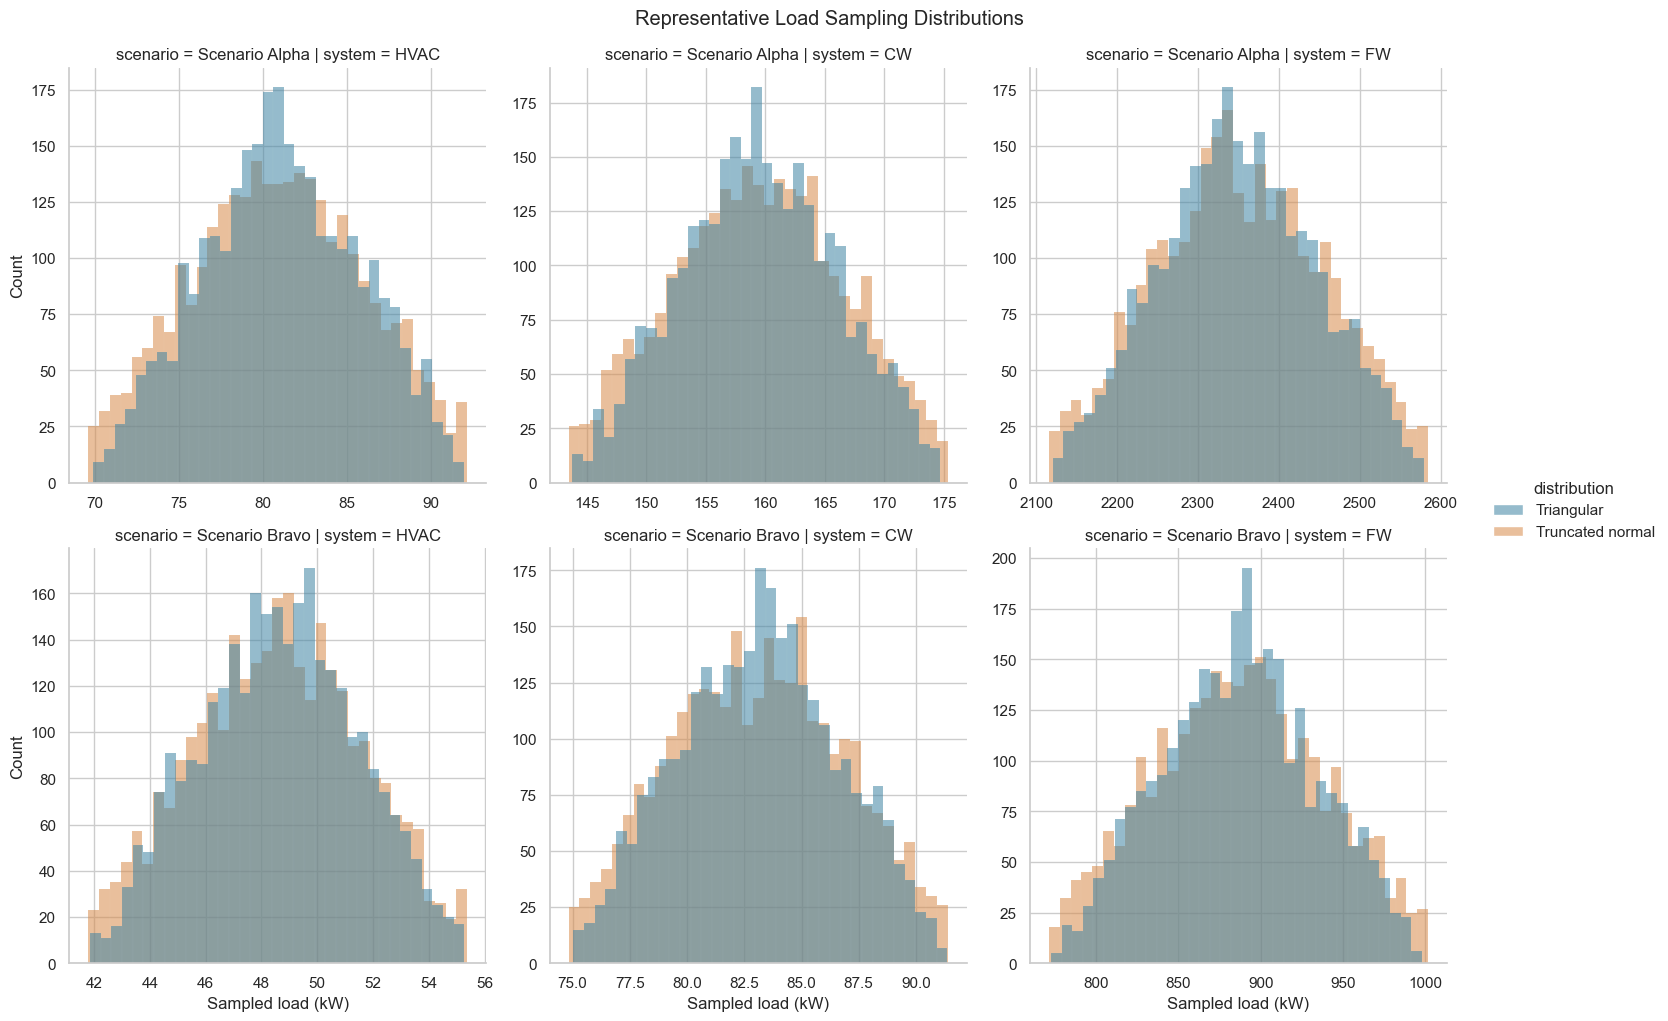

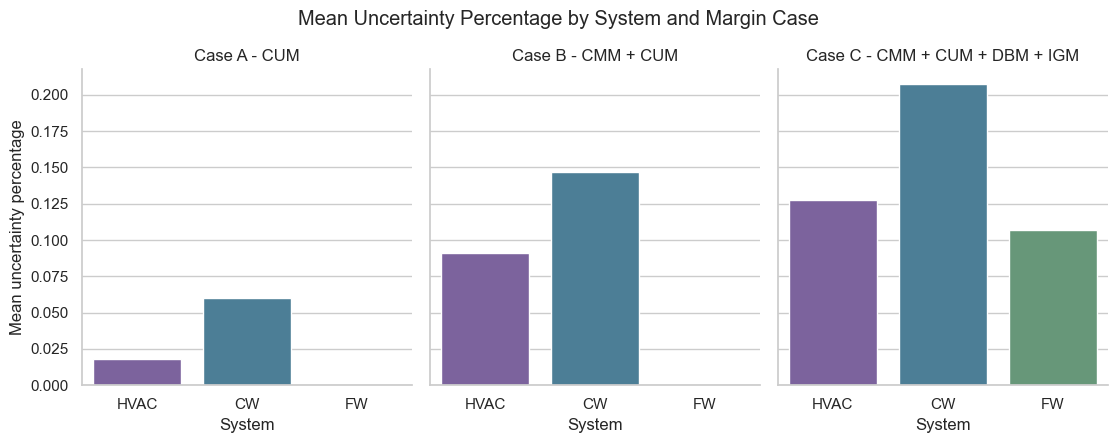

In [12]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    plot_rows = []
    plot_sample_size = 3000

    for _, row in example_parameters.iterrows():
        triangular_samples = sample_triangular(row, plot_sample_size, rng)
        for value in triangular_samples:
            plot_rows.append({
                "distribution": "Triangular",
                "system": row["system"],
                "scenario": row["scenario"],
                "margin_case": row["margin_case"],
                "sample_load_kw": value
            })

        if scipy_available:
            truncnorm_samples = sample_truncated_normal(row, plot_sample_size, rng)
            for value in truncnorm_samples:
                plot_rows.append({
                    "distribution": "Truncated normal",
                    "system": row["system"],
                    "scenario": row["scenario"],
                    "margin_case": row["margin_case"],
                    "sample_load_kw": value
                })

    plot_samples = pd.DataFrame(plot_rows)

    graph = sns.displot(
        data=plot_samples,
        x="sample_load_kw",
        hue="distribution",
        col="system",
        row="scenario",
        col_order=SYSTEM_ORDER,
        row_order=scenario_order,
        hue_order=["Triangular", "Truncated normal"],
        palette=DISTRIBUTION_PALETTE,
        kind="hist",
        bins=35,
        common_bins=False,
        facet_kws={"sharex": False, "sharey": False},
        alpha=0.55
    )
    graph.fig.suptitle("Representative Load Sampling Distributions", y=1.02)
    graph.set_axis_labels("Sampled load (kW)", "Count")
    graph.savefig(figures_output_path / "uncertainty_example_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

    graph = sns.catplot(
        data=parameter_summary,
        x="system",
        y="mean_uncertainty_pct",
        hue="system",
        col="margin_case",
        order=SYSTEM_ORDER,
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        kind="bar",
        height=4.2,
        aspect=0.9,
        dodge=False,
        legend=False,
        sharey=True,
    )
    graph.fig.suptitle("Mean Uncertainty Percentage by System and Margin Case", y=1.05)
    graph.set_axis_labels("System", "Mean uncertainty percentage")
    graph.set_titles("{col_name}")
    graph.savefig(figures_output_path / "uncertainty_margin_case_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed in this Python environment.")


## Uncertainty modelling decisions

The uncertainty parameter table is now ready to carry into Notebook 05. The key modelling decisions are:

1. Only local load rows are sampled.
2. Embedded propagation rows are excluded from local downstream sampling so that upstream load is not counted twice.
3. Blank scenario loads are converted to zero and remain zero when sampled.
4. Three margin cases are used to test how sensitive the result is to the interpretation of the engineering margins.
5. The triangular distribution uses the nominal load as the most likely value.
6. The truncated normal distribution uses the nominal load as the mean and uses the 95% interval assumption to estimate `sigma`.
7. Both distributions use the same lower and upper physical bounds.

This stage does not estimate overload probability yet. Its purpose is to make the assumptions explicit before the full Monte Carlo simulation is run.